# Telecom Churn — ML Model Building


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, make_scorer
%matplotlib inline

## 1. Load data

In [2]:
df = pd.read_csv('../artifacts/raw/data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.Churn.value_counts() / len(df) * 100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

## **Churn Rate**: ~26.5%
- 26.5% of customers churn — dataset is imbalanced

## 2. Quick baseline (raw data, no cleaning)

In [4]:
y_raw = df['Churn']
X_raw = df.drop(columns=['customerID', 'Churn'])
X_raw_enc = pd.get_dummies(X_raw, drop_first=True)
y_raw_enc = y_raw.map({'No': 0, 'Yes': 1})
X_tr, X_te, y_tr, y_te = train_test_split(X_raw_enc, y_raw_enc, test_size=0.2)
dt = DecisionTreeClassifier()
dt.fit(X_tr, y_tr)
print(classification_report(y_te, dt.predict(X_te)))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1042
           1       0.57      0.46      0.51       367

    accuracy                           0.77      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.76      0.77      0.76      1409



## 3. Data cleaning

In [5]:
telco = df.copy()
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
print('Nulls before drop:', telco['TotalCharges'].isnull().sum())
telco.dropna(how='any', inplace=True)
print(f'After cleaning: {len(telco)} rows')

Nulls before drop: 11
After cleaning: 7032 rows


## 4. Tenure binning (key feature engineering step)

In [6]:
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']
telco['tenure_bin'] = pd.cut(telco['tenure'], bins=bins, labels=labels, include_lowest=True)
print(telco[['tenure', 'tenure_bin']].head(10))
print('\nDistribution:')
print(telco['tenure_bin'].value_counts().sort_index())

   tenure tenure_bin
0       1       1-12
1      34      25-36
2       2       1-12
3      45      37-48
4       2       1-12
5       8       1-12
6      22      13-24
7      10       1-12
8      28      25-36
9      62      61-72

Distribution:
tenure_bin
1-12     2175
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: count, dtype: int64


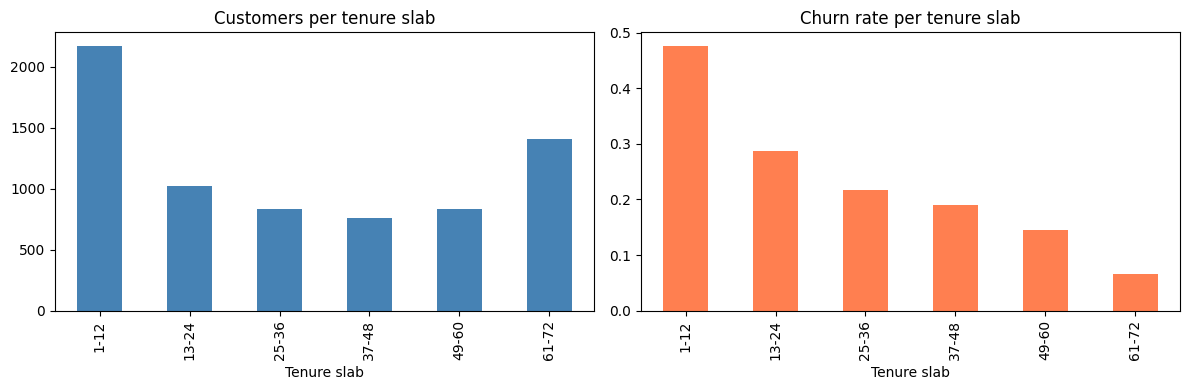

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

telco['tenure_bin'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Customers per tenure slab')
axes[0].set_xlabel('Tenure slab')

telco.groupby('tenure_bin')['Churn'] \
    .apply(lambda x: (x == 'Yes').mean()) \
    .plot(kind='bar', ax=axes[1], color='coral')

axes[1].set_title('Churn rate per tenure slab')
axes[1].set_xlabel('Tenure slab')

plt.tight_layout()
plt.show()

## 5. Feature engineering — X and y split

In [9]:
# Drop customerID, raw tenure (replaced by tenure_bin), and target
y = telco['Churn'].map({'No': 0, 'Yes': 1})
X = telco.drop(columns=['customerID', 'Churn', 'tenure'])
print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Shape of X: (7032, 19)
Shape of y: (7032,)


In [10]:
# One-hot encode with drop_first=True (same as notebook)
X = pd.get_dummies(X, drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
print('X shape after encoding:', X.shape)
print('Columns:', X.columns.tolist())

X shape after encoding: (7032, 34)
Columns: ['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_bin_13-24', 'tenure_bin_25-36', 'tenure_bin_37-48', 'tenure_bin_49-60', 'tenure_bin_61-72']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (5625, 34), Test: (1407, 34)


## 6. Feature scaling — StandardScaler

In [12]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

dt2 = DecisionTreeClassifier()
dt2.fit(X_train_sc, y_train)
print('DT + StandardScaler')
print(classification_report(y_test, dt2.predict(X_test_sc)))

DT + StandardScaler
              precision    recall  f1-score   support

           0       0.81      0.78      0.80      1033
           1       0.45      0.50      0.48       374

    accuracy                           0.71      1407
   macro avg       0.63      0.64      0.64      1407
weighted avg       0.72      0.71      0.71      1407



## 7. Feature scaling — MinMaxScaler

In [13]:
mms = MinMaxScaler()
X_train_mms = mms.fit_transform(X_train)
X_test_mms  = mms.transform(X_test)

dt3 = DecisionTreeClassifier()
dt3.fit(X_train_mms, y_train)
print('DT + MinMaxScaler')
print(classification_report(y_test, dt3.predict(X_test_mms)))

DT + MinMaxScaler
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      1033
           1       0.45      0.50      0.47       374

    accuracy                           0.70      1407
   macro avg       0.63      0.64      0.63      1407
weighted avg       0.71      0.70      0.71      1407



## 8. SMOTEENN — upsample + ENN clean

In [15]:
from imblearn.combine import SMOTEENN
from collections import Counter

sm = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = sm.fit_resample(X_train_sc, y_train)
print('Before SMOTEENN:', Counter(y_train))
print('After  SMOTEENN:', Counter(y_train_smoteenn))

Before SMOTEENN: Counter({0: 4130, 1: 1495})
After  SMOTEENN: Counter({1: 2986, 0: 2204})


In [16]:
dt_sm = DecisionTreeClassifier()
dt_sm.fit(X_train_smoteenn, y_train_smoteenn)
print('DT + SMOTEENN')
print(classification_report(y_test, dt_sm.predict(X_test_sc)))

DT + SMOTEENN
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407



In [17]:
rf_sm = RandomForestClassifier(n_estimators=500, random_state=42)
rf_sm.fit(X_train_smoteenn, y_train_smoteenn)
print('RandomForest (500) + SMOTEENN')
print(classification_report(y_test, rf_sm.predict(X_test_sc)))

RandomForest (500) + SMOTEENN
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1033
           1       0.49      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.74      1407



## 9. XGBoost experiments

In [18]:
from xgboost import XGBClassifier

# 9a — no resampling
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_sc, y_train)
print('XGBoost — no resampling')
print(classification_report(y_test, xgb.predict(X_test_sc)))

XGBoost — no resampling
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1033
           1       0.57      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.76      0.77      0.77      1407



In [19]:
# 9b — with SMOTEENN
xgb_sm = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_sm.fit(X_train_smoteenn, y_train_smoteenn)
print('XGBoost + SMOTEENN')
print(classification_report(y_test, xgb_sm.predict(X_test_sc)))

XGBoost + SMOTEENN
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [20]:
# 9c — with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)
print('Before SMOTE:', Counter(y_train))
print('After  SMOTE:', Counter(y_train_smote))

xgb_smote = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)
print('XGBoost + SMOTE')
print(classification_report(y_test, xgb_smote.predict(X_test_sc)))

Before SMOTE: Counter({0: 4130, 1: 1495})
After  SMOTE: Counter({0: 4130, 1: 4130})
XGBoost + SMOTE
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.55      0.56      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.76      0.76      0.76      1407



In [21]:
# 9d — ADASYN
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_sc, y_train)
print('Before ADASYN:', Counter(y_train))
print('After  ADASYN:', Counter(y_train_ad))

xgb_ad = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_ad.fit(X_train_ad, y_train_ad)
print('XGBoost + ADASYN')
print(classification_report(y_test, xgb_ad.predict(X_test_sc)))

Before ADASYN: Counter({0: 4130, 1: 1495})
After  ADASYN: Counter({0: 4130, 1: 4079})
XGBoost + ADASYN
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1033
           1       0.56      0.57      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.77      1407



In [22]:
# 9e — scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_w = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_w.fit(X_train_sc, y_train)
print('XGBoost + scale_pos_weight')
print(classification_report(y_test, xgb_w.predict(X_test_sc)))

scale_pos_weight: 2.76
XGBoost + scale_pos_weight
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407



## 10. AdaBoost with sample weighting

In [23]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
weight_positive = negative_count / positive_count
print(f'Neg: {negative_count}, Pos: {positive_count}, weight_pos: {weight_positive:.2f}')

sample_weight = np.where(y_train == 1, weight_positive, 1.0)

model_ada_weighted = AdaBoostClassifier(n_estimators=50, random_state=42)
model_ada_weighted.fit(X_train_sc, y_train, sample_weight=sample_weight)

y_pred_ada = model_ada_weighted.predict(X_test_sc)
print('AdaBoost with sample weighting')
print(classification_report(y_test, y_pred_ada))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_ada))

Neg: 4130, Pos: 1495, weight_pos: 2.76
AdaBoost with sample weighting
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Confusion matrix:
 [[726 307]
 [ 70 304]]


## 11. Hyperparameter tuning — RandomizedSearchCV (XGBoost)

In [24]:
param_grid = {
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'n_estimators':     [100, 200, 300, 400],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'scale_pos_weight': [1, scale_pos_weight],
}

xgb_rs = XGBClassifier(random_state=42, eval_metric='logloss')
search = RandomizedSearchCV(
    xgb_rs, param_grid, n_iter=50, cv=5,
    scoring='f1', random_state=42, n_jobs=-1
)
search.fit(X_train_sc, y_train)

print('Best params:', search.best_params_)
print('Best CV F1 :', search.best_score_)

best_xgb = search.best_estimator_
print('\nTest report:')
print(classification_report(y_test, best_xgb.predict(X_test_sc)))

Best params: {'subsample': 0.8, 'scale_pos_weight': np.float64(2.762541806020067), 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV F1 : 0.6363115660979201

Test report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [25]:
import pandas as pd

best_params_df = pd.DataFrame(
    list(search.best_params_.items()),
    columns=['Hyperparameter', 'Best Value']
)

print(best_params_df)

     Hyperparameter  Best Value
0         subsample    0.800000
1  scale_pos_weight    2.762542
2      n_estimators  400.000000
3  min_child_weight    5.000000
4         max_depth    4.000000
5     learning_rate    0.010000
6             gamma    0.000000
7  colsample_bytree    0.700000


In [ ]:
import joblib
joblib.dump(best_xgb, '../artifacts/models/best_xgboost_randomsearch.pkl')
print('Saved best_xgboost_randomsearch.pkl')

## 12. Optuna fine-tuning (XGBoost)

In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':       trial.suggest_int('n_estimators', 100, 1000),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
        'gamma':              trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha':          trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':         trial.suggest_float('reg_lambda', 0.0, 2.0),
        'scale_pos_weight':   trial.suggest_categorical('scale_pos_weight', [1, scale_pos_weight]),
        'random_state':       42,
        'eval_metric':        'logloss',
    }
    model = XGBClassifier(**params)
    f1_scorer = make_scorer(f1_score, average='binary', pos_label=1)
    return cross_val_score(model, X_train_sc, y_train, cv=5, scoring=f1_scorer, n_jobs=-1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print('Best params:', study.best_params)
print('Best CV F1 :', study.best_value)

best_optuna = XGBClassifier(**{**study.best_params, 'eval_metric': 'logloss', 'random_state': 42})
best_optuna.fit(X_train_sc, y_train)
print('\nTest report:')
print(classification_report(y_test, best_optuna.predict(X_test_sc)))

Best params: {'max_depth': 4, 'learning_rate': 0.02781184336323018, 'n_estimators': 177, 'subsample': 0.6549667332266306, 'colsample_bytree': 0.655335182287712, 'min_child_weight': 10, 'gamma': 0.4762352650426924, 'reg_alpha': 0.09356291893318991, 'reg_lambda': 0.9827167608371488, 'scale_pos_weight': np.float64(2.762541806020067)}
Best CV F1 : 0.642174885719007

Test report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407



In [29]:
import pandas as pd

best_params_df = pd.DataFrame(
    list(study.best_params.items()),
    columns=["Hyperparameter", "Best Value"]
)

print(best_params_df)

     Hyperparameter  Best Value
0         max_depth    4.000000
1     learning_rate    0.027812
2      n_estimators  177.000000
3         subsample    0.654967
4  colsample_bytree    0.655335
5  min_child_weight   10.000000
6             gamma    0.476235
7         reg_alpha    0.093563
8        reg_lambda    0.982717
9  scale_pos_weight    2.762542


In [ ]:
joblib.dump(best_optuna, '../artifacts/models/best_xgboost_optuna.pkl')
print('Saved best_xgboost_optuna.pkl')

## 13. Save production models (AdaBoost + best XGBoost)

In [ ]:
# AdaBoost — production model
joblib.dump(model_ada_weighted, '../artifacts/models/adaboost_model.pkl')
print('Saved adaboost_model.pkl')

# XGBoost — use Optuna best
joblib.dump(best_optuna, '../artifacts/models/xgboost_model.pkl')
print('Saved xgboost_model.pkl')

## 14. ROC curves comparison

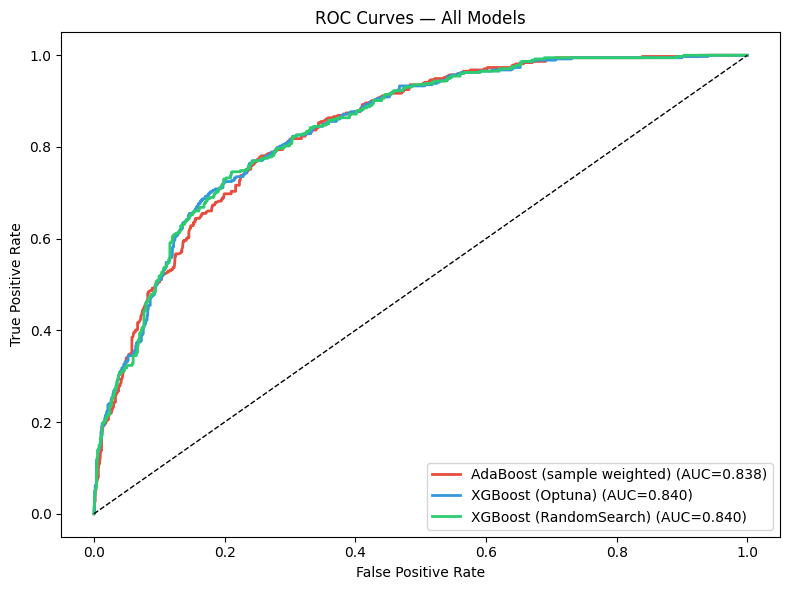

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))
for name, model, color in [
    ('AdaBoost (sample weighted)', model_ada_weighted, '#e74c3c'),
    ('XGBoost (Optuna)',           best_optuna,        '#3498db'),
    ('XGBoost (RandomSearch)',     best_xgb,           '#2ecc71'),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_sc)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()